**Формирование временных окон и сравнение архитектур автоэнкодеров: LSTM vs GRU vs TCN**

**Цель**: Эмпирический выбор оптимальной архитектуры для сжатия временных окон скважин.

**Этапы**:
1. Формирование скользящих окон (ЭЦН: 180×9, ШГН: 100×9)
2. Подбор оптимальной размерности латентного пространства (4–7 измерений)
3. Обучение и валидация автоэнкодеров
4. Визуализация качества реконструкции

**Вход**: ../data/processed/{ecn,shgn}_{train,val,test}.csv + scaler_*.pkl  
**Выход**: models/{ecn,shgn}/model.pth + scaler.pkl

In [ ]:
import copy  # noqa: I001
import logging
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

# ==== КОНФИГУРАЦИЯ И ЦВЕТОВАЯ СХЕМА ====

In [2]:
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s", handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

In [155]:
COLORS = {
    "primary": "#2E86AB",
    "secondary": "#A23B72",
    "accent": "#F18F01",
    "success": "#C73E1D",
    "neutral": "#6B7280",
}

ARCH_COLORS = {"LSTM": COLORS["primary"], "GRU": COLORS["secondary"], "TCN": COLORS["accent"]}

plt.rcParams.update(
    {
        "figure.figsize": (15, 6),
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "figure.dpi": 100,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    }
)

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("models")
FEATURE_COLUMNS = [
    "us_center",
    "us_periph",
    "gas_center",
    "gas_periph",
    "temp",
    "water_center",
    "water_periph",
    "gas_integral",
    "water_integral",
]

WINDOW_SIZES = {"ecn": 180, "shgn": 100}
LATENT_DIMS = [50, 100, 500]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Устройство: {DEVICE}")

2026-02-19 22:01:29,151 - INFO - Устройство: cuda


# ==== 1. ЗАГРУЗКА ДАННЫХ И ФОРМИРОВАНИЕ ОКОН ====

In [96]:
def load_and_create_windows(prefix: str, window_size: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
    train = pd.read_csv(DATA_DIR / f"{prefix}_train.csv", parse_dates=["timestamp"])
    val = pd.read_csv(DATA_DIR / f"{prefix}_val.csv", parse_dates=["timestamp"])
    test = pd.read_csv(DATA_DIR / f"{prefix}_test.csv", parse_dates=["timestamp"])

    with open(DATA_DIR / f"scaler_{prefix}.pkl", "rb") as f:
        scaler = pickle.load(f)

    def create_windows(df: pd.DataFrame) -> np.ndarray:
        X = df[FEATURE_COLUMNS].values
        well_ids = df["well"].values if "well" in df.columns else None
        windows = []

        for i in range(0, len(X) - window_size + 1):
            if well_ids is not None:
                if len(set(well_ids[i : i + window_size])) > 1:
                    continue
            windows.append(X[i : i + window_size])

        return np.array(windows, dtype=np.float32)

    X_train = create_windows(train)
    X_val = create_windows(val)
    X_test = create_windows(test)

    logger.info(f"{prefix.upper()}: окна — train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")
    return X_train, X_val, X_test, scaler

In [97]:
X_ecn_train, X_ecn_val, X_ecn_test, scaler_ecn = load_and_create_windows("ecn", WINDOW_SIZES["ecn"])
X_shgn_train, X_shgn_val, X_shgn_test, scaler_shgn = load_and_create_windows("shgn", WINDOW_SIZES["shgn"])

2026-02-19 21:36:44,330 - INFO - ECN: окна — train=(30843, 180, 9), val=(6469, 180, 9), test=(6469, 180, 9)
2026-02-19 21:36:45,145 - INFO - SHGN: окна — train=(72404, 100, 9), val=(13436, 100, 9), test=(4599, 100, 9)


In [6]:
def plot_random_window(X: np.ndarray, window_size: int, pump_type: str, color: str) -> None:
    if len(X) == 0:
        logger.warning(f"Empty dataset for {pump_type} window plotting")
        return

    idx = np.random.randint(0, len(X))
    window = X[idx]

    fig, axes = plt.subplots(3, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, feature in enumerate(FEATURE_COLUMNS):
        axes[i].plot(window[:, i], color=color, linewidth=2.5, alpha=0.9)
        axes[i].set_title(feature, fontsize=11, fontweight="bold", color=color)
        axes[i].set_xlabel("Время (×10 сек)", fontsize=9)
        axes[i].grid(True, alpha=0.4, linestyle="-", linewidth=0.7)

    duration_min = window_size * 10 / 60
    fig.suptitle(
        f"{pump_type}: случайное окно #{idx} ({window_size} точек = {duration_min:.1f} мин)",
        fontsize=15,
        fontweight="bold",
        y=0.995,
        color=color,
    )
    plt.tight_layout()
    plt.show()
    plt.close(fig)

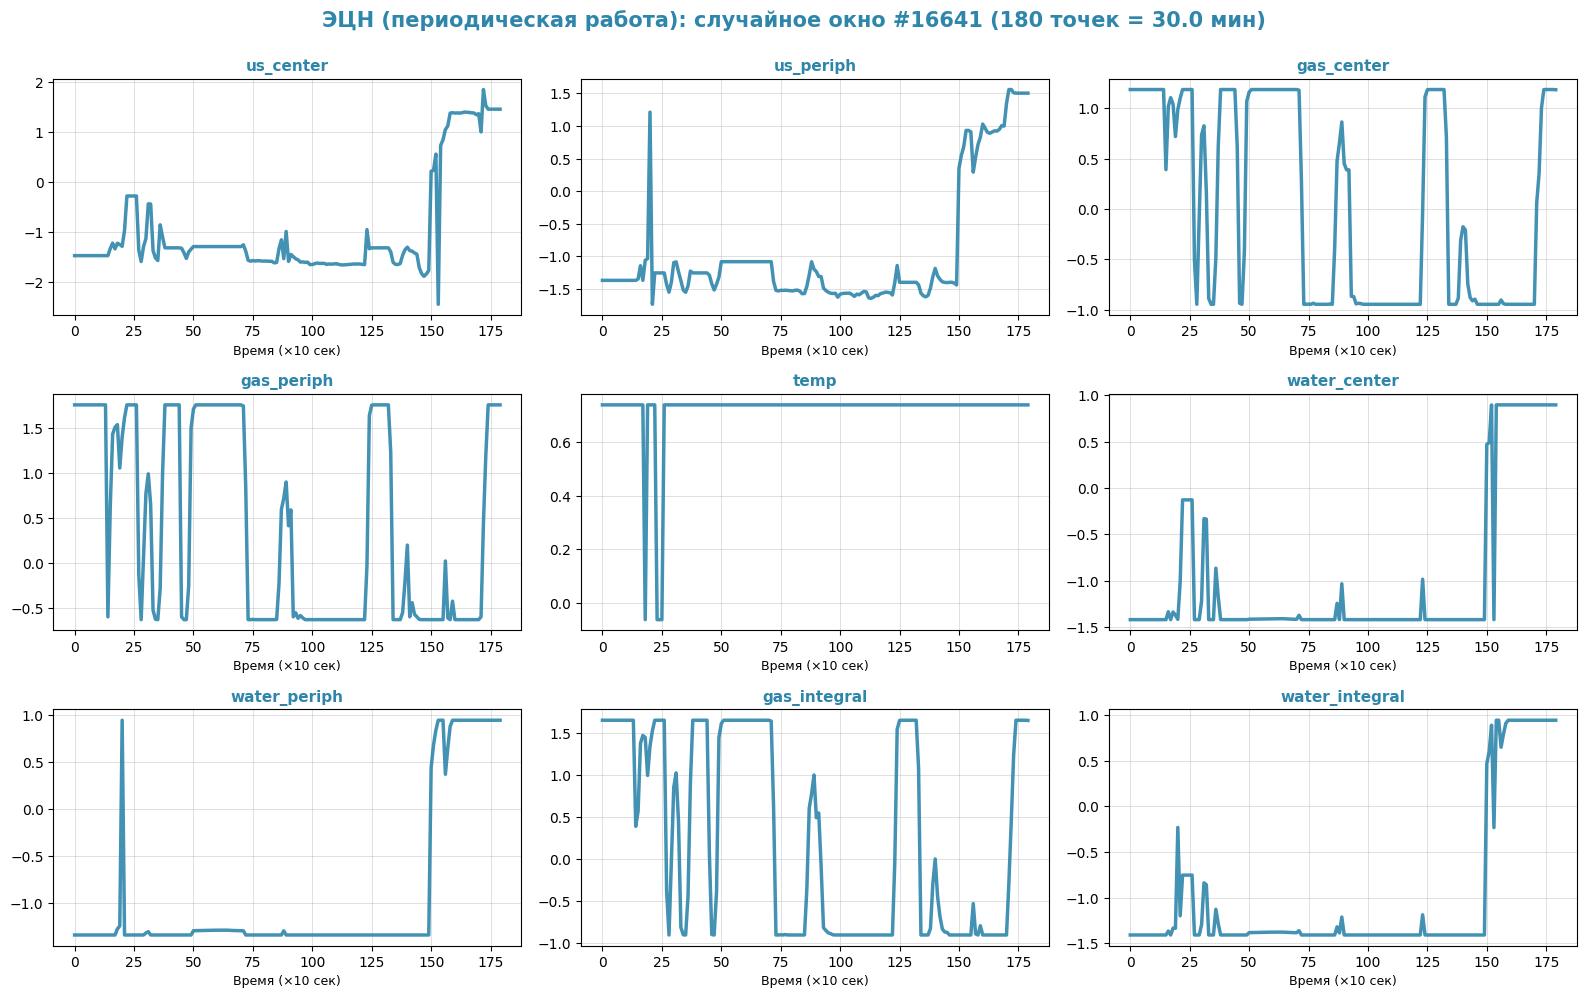

In [8]:
plot_random_window(X_ecn_train, WINDOW_SIZES["ecn"], "ЭЦН (периодическая работа)", COLORS["primary"])

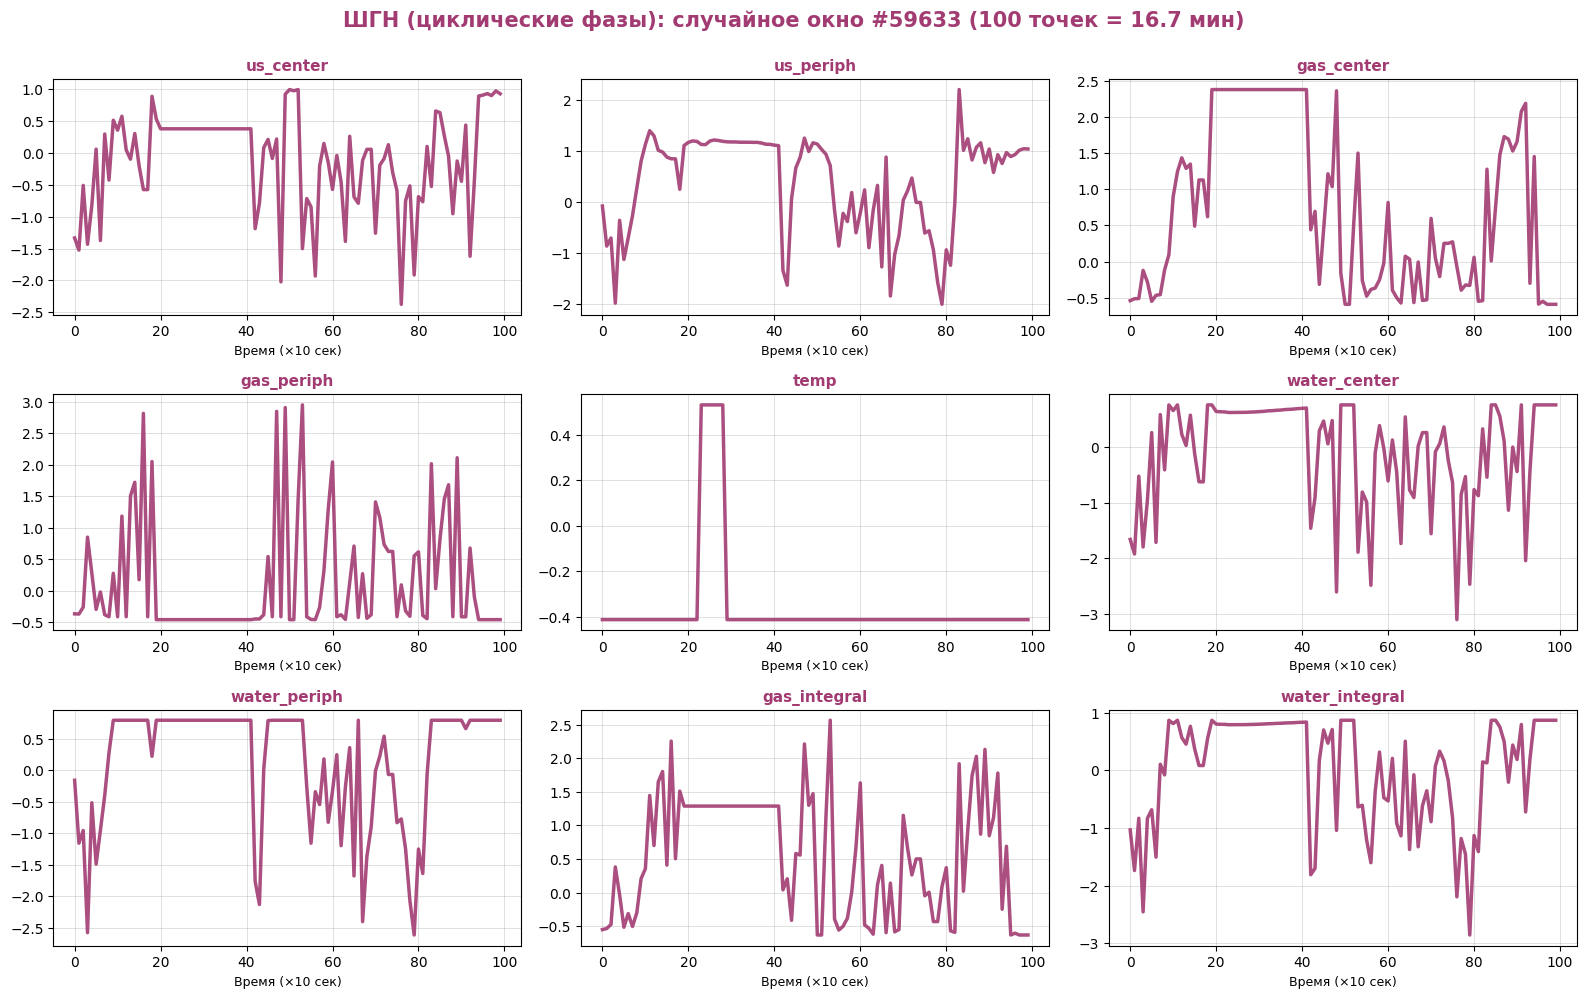

In [9]:
plot_random_window(X_shgn_train, WINDOW_SIZES["shgn"], "ШГН (циклические фазы)", COLORS["secondary"])

# ==== 2. АРХИТЕКТУРЫ АВТОЭНКОДЕРОВ ====

In [156]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_size: int, latent_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.latent_dim = latent_dim

        self.encoder = nn.LSTM(
            input_dim, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )

        self.bottleneck = nn.Linear(hidden_size, latent_dim)

        self.decoder_input_proj = nn.Linear(latent_dim + 1, hidden_size)

        self.decoder = nn.LSTM(
            hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.output = nn.Linear(hidden_size, input_dim)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        _, (h_n, _) = self.encoder(x)
        h_pooled = h_n.mean(dim=0)
        z = self.bottleneck(h_pooled)
        return z

    def decode(self, z: torch.Tensor, seq_len: int) -> torch.Tensor:
        batch_size = z.size(0)
        device = z.device

        z_expanded = z.unsqueeze(1).repeat(1, seq_len, 1)

        time_steps = torch.arange(seq_len, device=device).float().unsqueeze(0).unsqueeze(-1)
        time_steps = time_steps.repeat(batch_size, 1, 1) / seq_len

        decoder_input = torch.cat([z_expanded, time_steps], dim=-1)

        decoder_input = self.decoder_input_proj(decoder_input)

        outputs, _ = self.decoder(decoder_input)

        return self.output(outputs)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        z = self.encode(x)
        recon = self.decode(z, x.size(1))
        return recon, z

In [157]:
class GRUAutoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_size: int, latent_dim: int, num_layers: int, dropout: float):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.latent_dim = latent_dim

        self.encoder = nn.GRU(
            input_dim, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )

        self.bottleneck = nn.Linear(hidden_size, latent_dim)

        self.decoder_input_proj = nn.Linear(latent_dim + 1, hidden_size)

        self.decoder = nn.GRU(
            hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.output = nn.Linear(hidden_size, input_dim)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        _, h_n = self.encoder(x)
        h_pooled = h_n.mean(dim=0)
        z = self.bottleneck(h_pooled)
        return z

    def decode(self, z: torch.Tensor, seq_len: int) -> torch.Tensor:
        batch_size = z.size(0)
        device = z.device

        z_expanded = z.unsqueeze(1).repeat(1, seq_len, 1)

        time_steps = torch.arange(seq_len, device=device).float().unsqueeze(0).unsqueeze(-1)
        time_steps = time_steps.repeat(batch_size, 1, 1) / seq_len

        decoder_input = torch.cat([z_expanded, time_steps], dim=-1)

        decoder_input = self.decoder_input_proj(decoder_input)

        outputs, _ = self.decoder(decoder_input)

        return self.output(outputs)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        z = self.encode(x)
        recon = self.decode(z, x.size(1))
        return recon, z

In [160]:
class CausalConv1d(nn.Conv1d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, dilation=1, groups=1, bias=True):
        super().__init__(
            in_channels,
            out_channels,
            kernel_size,
            stride=stride,
            padding=0,
            dilation=dilation,
            groups=groups,
            bias=bias,
        )
        self.causal_padding = (kernel_size - 1) * dilation

    def forward(self, x):
        x_padded = F.pad(x, (self.causal_padding, 0))
        return super().forward(x_padded)


class TemporalBlock(nn.Module):
    def __init__(self, n_in, n_out, kernel_size, dilation, dropout=0.2):
        super().__init__()
        self.conv1 = CausalConv1d(n_in, n_out, kernel_size, dilation=dilation)
        self.norm1 = nn.BatchNorm1d(n_out)
        self.act1 = nn.PReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = CausalConv1d(n_out, n_out, kernel_size, dilation=dilation)
        self.norm2 = nn.BatchNorm1d(n_out)
        self.drop2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(n_in, n_out, 1) if n_in != n_out else None
        self.final_act = nn.PReLU()

    def forward(self, x):
        res = x if self.downsample is None else self.downsample(x)

        out = self.conv1(x)
        out = self.norm1(out)
        out = self.act1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.norm2(out)
        out = self.drop2(out)

        out = self.final_act(out + res)
        return out


class TCNAutoencoder(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_size: int,
        latent_dim: int,
        num_layers: int,
        kernel_size: int,
        dilation_base: int = 2,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.latent_dim = latent_dim
        self.num_layers = num_layers
        self.kernel_size = kernel_size
        self.dilation_base = dilation_base

        self.encoder = nn.ModuleList(
            [
                TemporalBlock(input_dim if i == 0 else hidden_size, hidden_size, kernel_size, dilation_base**i, dropout)
                for i in range(num_layers)
            ]
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.bottleneck = nn.Linear(hidden_size, latent_dim)

        self.decoder_bridge = nn.Sequential(nn.Linear(latent_dim, hidden_size), nn.PReLU())

        self.upsample_layers = nn.ModuleList(
            [
                nn.ConvTranspose1d(
                    hidden_size,
                    hidden_size,
                    kernel_size=4,
                    stride=2,
                    padding=1,
                    output_padding=1,
                )
                for _ in range(num_layers)
            ]
        )

        self.decoder = nn.ModuleList(
            [TemporalBlock(hidden_size, hidden_size, kernel_size, dilation_base**i, dropout) for i in range(num_layers)]
        )

        self.output_conv = nn.Conv1d(hidden_size, input_dim, 1)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        x = x.transpose(1, 2)
        for layer in self.encoder:
            x = layer(x)
        pooled = self.global_pool(x).squeeze(-1)
        return self.bottleneck(pooled)

    def decode(self, z: torch.Tensor, seq_len: int) -> torch.Tensor:
        h = self.decoder_bridge(z).unsqueeze(-1)  # [B, C, 1] ← 3D!

        for upsample_layer in self.upsample_layers:
            h = upsample_layer(h)
            h = F.relu(h)

        h = F.interpolate(h, size=seq_len, mode="linear", align_corners=False)

        for layer in self.decoder:
            h = layer(h)

        return self.output_conv(h).transpose(1, 2)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        z = self.encode(x)
        recon = self.decode(z, x.size(1))
        return recon, z

#  ==== 3. ОБУЧЕНИЕ И ВАЛИДАЦИЯ ====

In [161]:
def create_dataloaders(X_train, X_val, X_test, batch_size=128):
    loaders = {}
    for name, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
        tensor = torch.from_numpy(X).float()
        ds = TensorDataset(tensor)
        loaders[name] = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=(name == "train"),
            drop_last=(name == "train"),
            num_workers=0,
            pin_memory=False,
        )
    return loaders["train"], loaders["val"], loaders["test"]

In [175]:
def compute_loss(recon, x_batch, recon_weight):
    mse_loss = F.mse_loss(recon, x_batch)
    return recon_weight * mse_loss, mse_loss

In [163]:
def train_epoch(model, train_loader, optimizer, device, recon_weight):
    model.train()
    total_loss = total_mae = 0
    samples = 0

    for batch in train_loader:
        x_batch = batch[0].to(device)
        optimizer.zero_grad(set_to_none=True)

        recon, _ = model(x_batch)
        loss, _ = compute_loss(recon, x_batch, recon_weight)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        with torch.no_grad():
            mae = F.l1_loss(recon, x_batch).item()

        total_loss += loss.item() * x_batch.size(0)
        total_mae += mae * x_batch.size(0)
        samples += x_batch.size(0)

    return total_loss / samples, total_mae / samples

In [164]:
def evaluate_epoch(model, data_loader, device, recon_weight):
    model.eval()
    total_loss = total_mae = 0
    samples = 0

    with torch.no_grad():
        for batch in data_loader:
            x_batch = batch[0].to(device)
            recon, _ = model(x_batch)
            loss, _ = compute_loss(recon, x_batch, recon_weight)
            mae = F.l1_loss(recon, x_batch).item()

            total_loss += loss.item() * x_batch.size(0)
            total_mae += mae * x_batch.size(0)
            samples += x_batch.size(0)

    return total_loss / samples, total_mae / samples

In [ ]:
HYPERPARAMS = {
    "input_dim": len(FEATURE_COLUMNS),
    "hidden_size": 128,
    "num_layers": 2,
    "kernel_size": 5,
    "dilation_base": 3,
    "dropout": 0.3,
    "epochs": 50,
    "batch_size": 256,
    "lr": 3e-4,
    "weight_decay": 5e-4,
    "patience": 15,
    "recon_weight": 1.0,
    "eta_min": 1e-6,
}

In [166]:
def train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    epochs,
    lr,
    weight_decay,
    patience,
    recon_weight,
    eta_min,
    device="cuda",
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=eta_min)

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "val_mae": [], "train_mae": [], "lr": []}

    for _ in tqdm(range(epochs), desc="Обучение", unit="epoch"):
        train_loss, train_mae = train_epoch(model, train_loader, optimizer, device, recon_weight)
        val_loss, val_mae = evaluate_epoch(model, val_loader, device, recon_weight)

        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_mae"].append(train_mae)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)
        history["lr"].append(current_lr)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_mae = evaluate_epoch(model, test_loader, device, recon_weight)

    valid_history = {k: v[: len(history["val_loss"])] for k, v in history.items()}
    best_epoch = np.argmin(valid_history["val_loss"])

    return {
        "best_val_loss": best_val_loss,
        "best_val_mae": valid_history["val_mae"][best_epoch],
        "test_loss": test_loss,
        "test_mae": test_mae,
        "history": valid_history,
    }

In [167]:
def compare_architectures_single(name, ModelFactory, train_loader, val_loader, test_loader, device):
    best_arch_result = None
    all_results = []

    specific_params = {}
    if name == "TCN":
        specific_params = {"dropout": 0.3, "weight_decay": 5e-4}
    else:
        specific_params = {"dropout": 0.2, "weight_decay": 1e-4}

    for latent_dim in LATENT_DIMS:
        model = ModelFactory(latent_dim).to(device)

        curr_weight_decay = specific_params.get("weight_decay", HYPERPARAMS["weight_decay"])

        metrics = train_model(
            model,
            train_loader,
            val_loader,
            test_loader,
            epochs=HYPERPARAMS["epochs"],
            lr=HYPERPARAMS["lr"],
            weight_decay=curr_weight_decay,
            patience=HYPERPARAMS["patience"],
            recon_weight=HYPERPARAMS["recon_weight"],
            eta_min=HYPERPARAMS["eta_min"],
            device=device,
        )

        current_val_loss = metrics["best_val_loss"]

        all_results.append(
            {
                "latent_dim": latent_dim,
                "val_loss": current_val_loss,
                "val_mae": metrics["best_val_mae"],
                "test_loss": metrics["test_loss"],
                "test_mae": metrics["test_mae"],
            }
        )

        if best_arch_result is None or current_val_loss < best_arch_result["val_loss"]:
            best_arch_result = {
                "latent_dim": latent_dim,
                "val_loss": current_val_loss,
                "val_mae": metrics["best_val_mae"],
                "test_loss": metrics["test_loss"],
                "test_mae": metrics["test_mae"],
                "state_dict": copy.deepcopy(model.state_dict()),
                "history": metrics["history"],
            }

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return {
        "best": best_arch_result,
        "all": all_results,
        "color": ARCH_COLORS.get(name, "#0EF12C"),
    }

In [171]:
def plot_architecture_comparison(results, pump_type):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    for name, res in results.items():
        dims = [r["latent_dim"] for r in res["all"]]
        losses = [r["val_loss"] for r in res["all"]]
        ax1.plot(dims, losses, marker="o", linewidth=2.5, markersize=9, label=name, color=res["color"])

    ax1.set_xlabel("Размерность латентного пространства", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Validation MSE", fontsize=12, fontweight="bold")
    ax1.set_title(f"{pump_type}: сравнение архитектур", fontsize=14, fontweight="bold")
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.4)

    best_arch = min(results, key=lambda x: results[x]["best"]["val_loss"])

    table_data = []
    for name in results.keys():
        best = results[name]["best"]
        table_data.append(
            [
                name,
                f"{best['latent_dim']}",
                f"{best['val_loss']:.5f}",
                f"{best['val_mae']:.5f}",
                f"{best['test_loss']:.5f}",
            ]
        )

    table = ax2.table(
        cellText=table_data,
        colLabels=["Архитектура", "Latent dim", "Val MSE", "Val MAE", "Test MSE"],
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.2)

    for i, name in enumerate(results.keys()):
        color = "#90EE90" if name == best_arch else "white"
        for j in range(5):
            table[(i + 1, j)].set_facecolor(color)

    ax2.axis("off")
    ax2.set_title(f"{pump_type}: сравнение по метрикам", fontsize=14, fontweight="bold", pad=20)

    plt.tight_layout()
    plt.show()

    return best_arch, results[best_arch]["best"]["latent_dim"]

In [169]:
def evaluate_architectures(X_train, X_val, X_test, pump_type, device=DEVICE, random_seed=42):
    torch.manual_seed(random_seed)

    architectures = {
        "TCN": lambda latent_dim: TCNAutoencoder(
            input_dim=HYPERPARAMS["input_dim"],
            hidden_size=HYPERPARAMS["hidden_size"],
            latent_dim=latent_dim,
            num_layers=HYPERPARAMS["num_layers"],
            kernel_size=HYPERPARAMS["kernel_size"],
            dilation_base=HYPERPARAMS["dilation_base"],
            dropout=HYPERPARAMS["dropout"],
        ),
        "LSTM": lambda latent_dim: LSTMAutoencoder(
            input_dim=HYPERPARAMS["input_dim"],
            hidden_size=HYPERPARAMS["hidden_size"],
            latent_dim=latent_dim,
            num_layers=HYPERPARAMS["num_layers"],
            dropout=HYPERPARAMS["dropout"],
        ),
        "GRU": lambda latent_dim: GRUAutoencoder(
            input_dim=HYPERPARAMS["input_dim"],
            hidden_size=HYPERPARAMS["hidden_size"],
            latent_dim=latent_dim,
            num_layers=HYPERPARAMS["num_layers"],
            dropout=HYPERPARAMS["dropout"],
        ),
    }

    results = {}
    train_loader, val_loader, test_loader = create_dataloaders(
        X_train, X_val, X_test, batch_size=HYPERPARAMS["batch_size"]
    )

    for name, ModelFactory in architectures.items():
        logger.info(f"Training {name}...")
        results[name] = compare_architectures_single(name, ModelFactory, train_loader, val_loader, test_loader, device)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    best_arch, best_dim = plot_architecture_comparison(results, pump_type)

    best_model = architectures[best_arch](best_dim).to(device)
    best_model.load_state_dict(results[best_arch]["best"]["state_dict"])
    best_model.eval()

    return results, best_arch, best_model

# ==== 4. СРАВНЕНИЕ ДЛЯ ЭЦН ====

2026-02-19 22:06:14,346 - INFO - Training TCN...
Обучение:  18%|█▊        | 18/100 [02:39<12:04,  8.84s/epoch]
2026-02-19 22:15:24,963 - INFO - Training LSTM...
Обучение:  30%|███       | 30/100 [03:35<08:22,  7.18s/epoch]
2026-02-19 22:25:01,002 - INFO - Training GRU...
Обучение:  32%|███▏      | 32/100 [02:47<05:56,  5.24s/epoch]


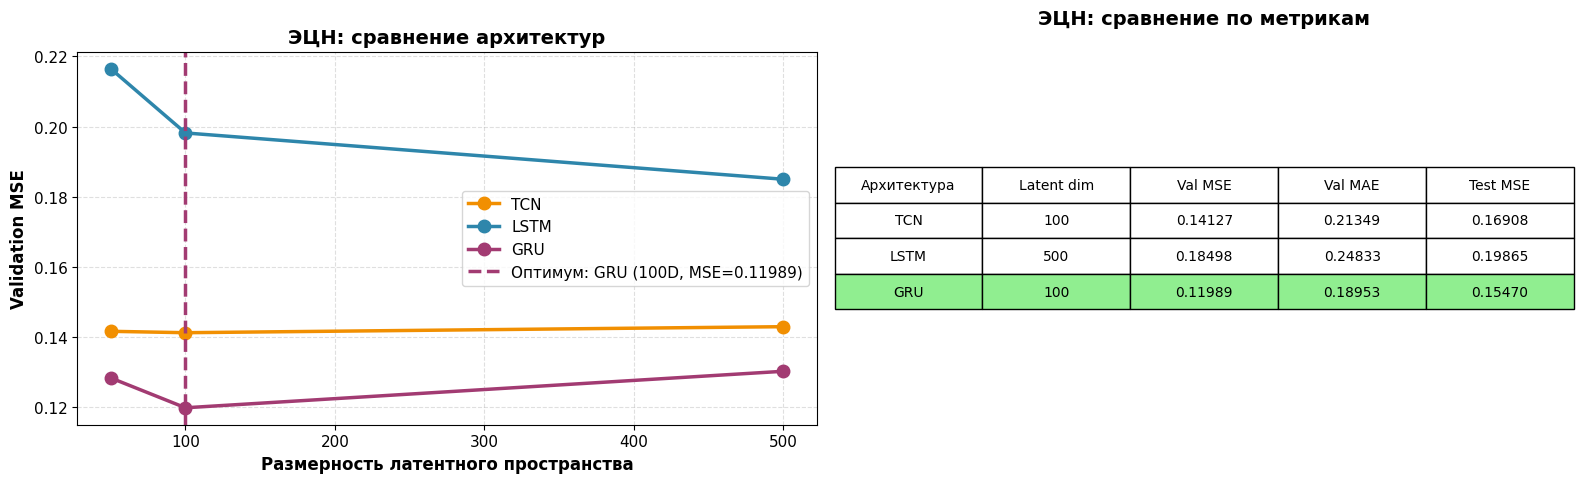

In [170]:
ecn_results, ecn_best_arch, ecn_best_model = evaluate_architectures(
    X_ecn_train, X_ecn_val, X_ecn_test, "ЭЦН"
)

In [173]:
def plot_architectures_comparison(ecn_results: dict) -> None:
    _, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, (arch_name, arch_result) in enumerate(ecn_results.items()):
        ax = axes[i]
        best_history = arch_result["best"]["history"]
        n_epochs = len(best_history["train_loss"])
        epochs = np.arange(n_epochs)

        color = ARCH_COLORS.get(arch_name, "#6B7280")
        ax.plot(epochs, best_history["train_loss"], color=color, label="Train", linewidth=2)
        ax.plot(epochs, best_history["val_loss"], color=color, linestyle="--", label="Val", linewidth=2)
        ax.set_title(f"{arch_name}\nMSE={arch_result['best']['val_loss']:.4f}", fontsize=14)
        ax.set_ylabel("MSE")
        ax.set_xlabel("Эпохи")
        ax.legend(fontsize=11)
        ax.grid(alpha=0.3, linestyle="--")

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))

    plt.tight_layout()
    plt.show()

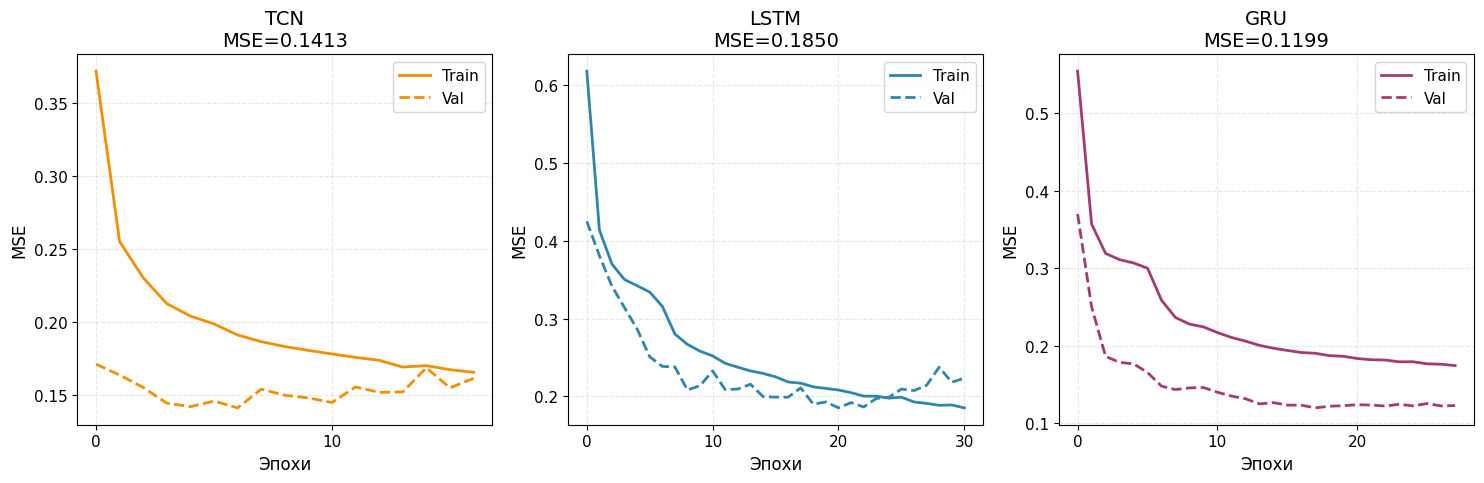

In [174]:
plot_architectures_comparison(ecn_results)

# ==== 5. СРАВНЕНИЕ ДЛЯ ШГН ====

In [ ]:
shgn_results, shgn_best_arch, shgn_best_model = evaluate_architectures(
    X_shgn_train, X_shgn_val, X_shgn_test, "ШГН"
)

# ==== 6. ВИЗУАЛИЗАЦИЯ РЕКОНСТРУКЦИИ ====

In [180]:
def plot_reconstruction(model, X_val, pump_type: str, color: str) -> None:
    model.eval()

    if not isinstance(X_val, np.ndarray):
        X_val = np.array(X_val)

    idx = np.random.choice(len(X_val))
    duration_min = X_val.shape[1] * 10 / 60

    fig, axes = plt.subplots(3, 3, figsize=(20, 12))
    axes = axes.flatten()

    with torch.no_grad():
        x = torch.FloatTensor(X_val[idx]).unsqueeze(0).to(DEVICE)
        recon, _ = model(x)

        mse = F.mse_loss(recon, x).item()
        mae = F.l1_loss(recon, x).item()
        logger.info(f"Окно #{idx}: MSE={mse:.6f}, MAE={mae:.4f}")

        x_np = x[0].cpu().numpy()
        recon_np = recon[0].cpu().numpy()

        for col_idx, feature in enumerate(FEATURE_COLUMNS):
            ax = axes[col_idx]
            time_steps = np.arange(X_val.shape[1])

            ax.plot(time_steps, x_np[:, col_idx], color="#1f77b4", linewidth=2.5, label="Input", zorder=3)
            ax.plot(time_steps, recon_np[:, col_idx], color="#d62728", linewidth=2, label="Reconstruction", zorder=2)
            ax.fill_between(
                time_steps, x_np[:, col_idx], recon_np[:, col_idx], color="#ff9896", alpha=0.5, label="Error", zorder=1
            )

            ax.set_title(feature, fontsize=12, fontweight="bold")
            ax.grid(True, alpha=0.3, linestyle="--")

            if col_idx >= 6:
                ax.set_xlabel("Time (×10 sec)", fontsize=11)
            if col_idx in [0, 3, 6]:
                ax.set_ylabel("Value", fontsize=10)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=11)

    window_info = f"{pump_type} (window {X_val.shape[1]} points = {duration_min:.1f} min)"
    model_name = model.__class__.__name__.replace("Autoencoder", "")
    fig.suptitle(f"{window_info}: Reconstruction Quality ({model_name})", fontsize=16, fontweight="bold", y=0.995)

    plt.tight_layout(rect=(0, 0.02, 1, 0.96))
    plt.show()

2026-02-19 22:41:04,173 - INFO - Окно #2179: MSE=0.122050, MAE=0.1763


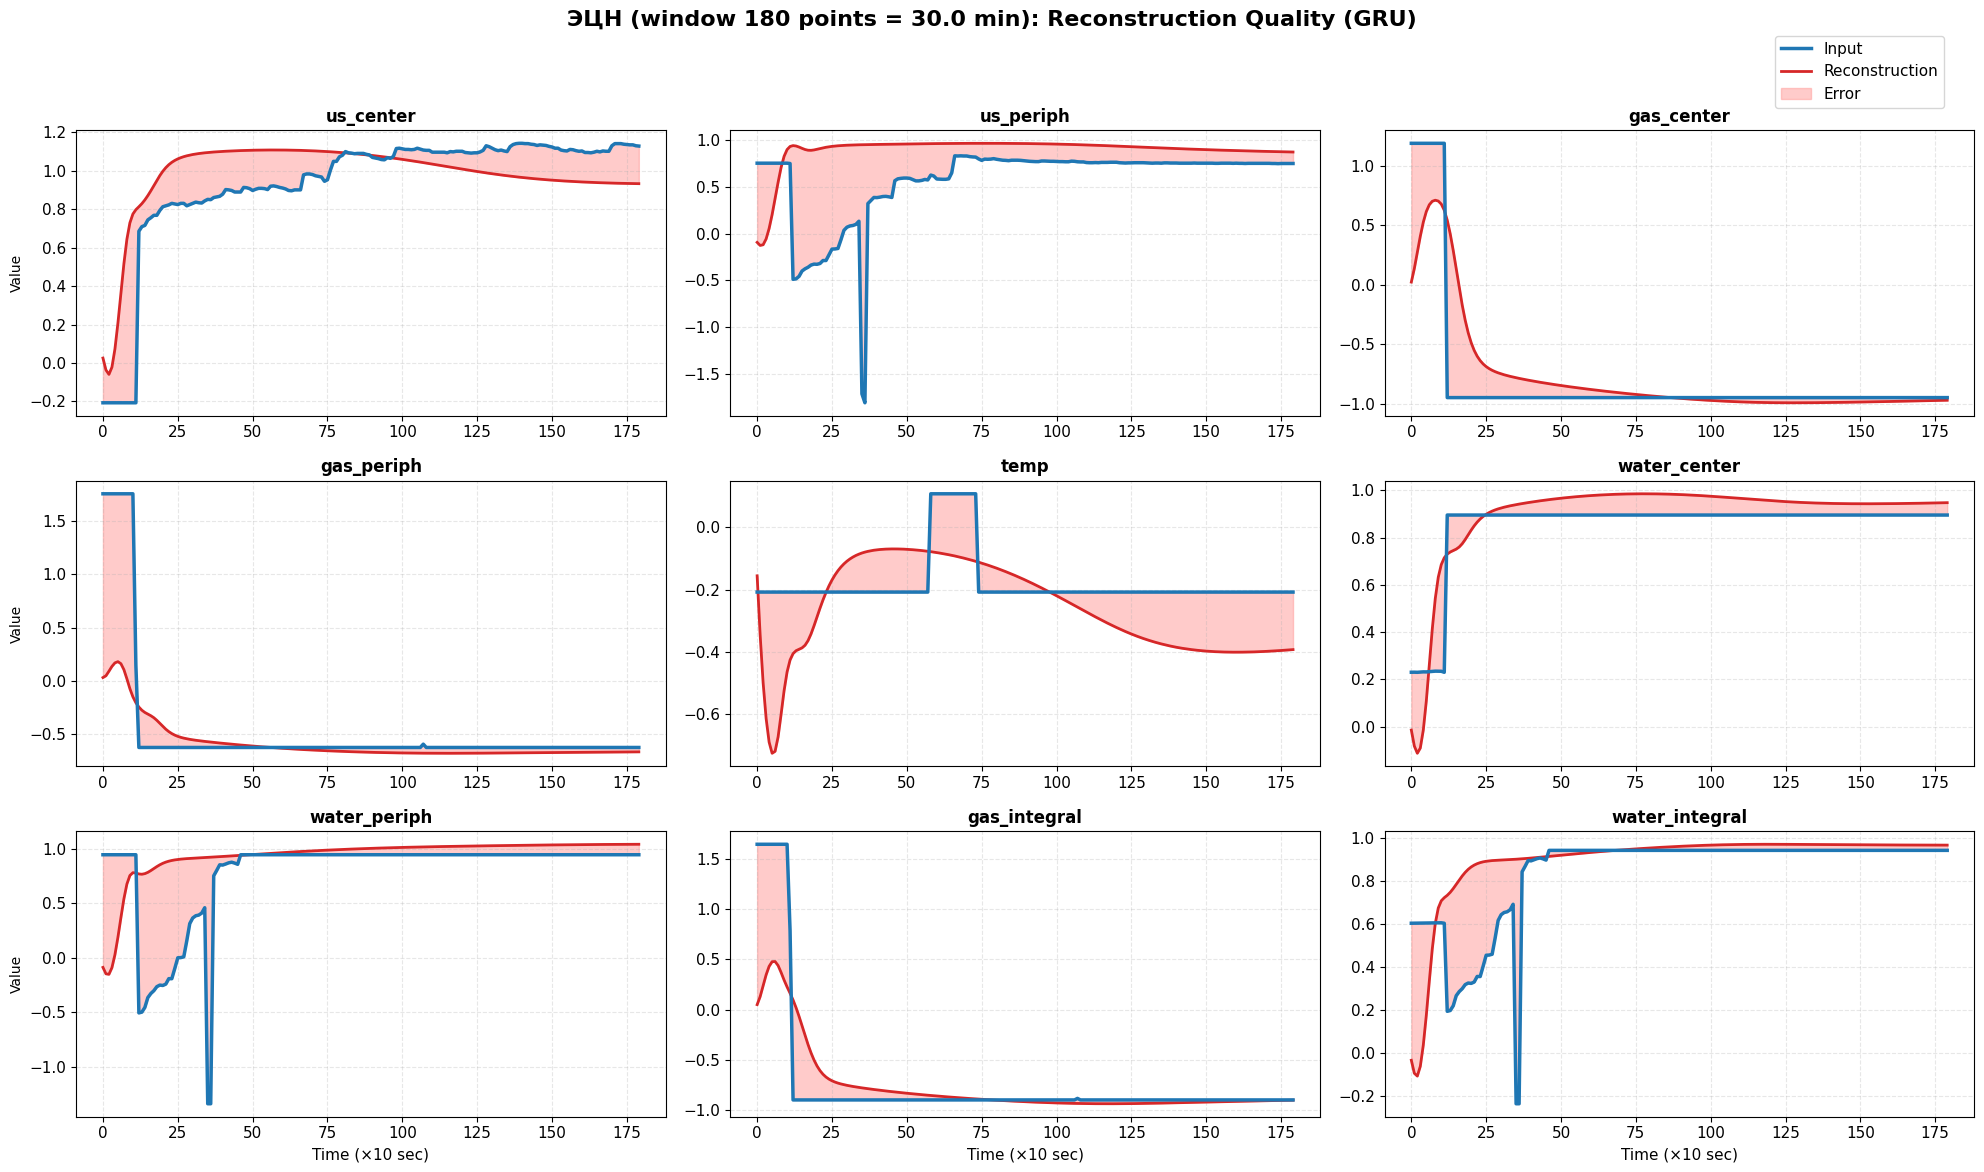

In [181]:
plot_reconstruction(ecn_best_model, X_ecn_val, "ЭЦН", COLORS["primary"])

In [ ]:
plot_reconstruction(shgn_best_model, X_shgn_val, "ШГН", COLORS["secondary"])

# ==== 7. СОХРАНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ ====

In [48]:
def save_model(model, scaler, prefix, best_arch, latent_dim, metrics, window_size):
    model_dir = MODELS_DIR / prefix
    model_dir.mkdir(parents=True, exist_ok=True)

    metrics_full = {
        "val_loss": metrics["val_loss"],
        "val_mae": metrics["val_mae"],
        "test_loss": metrics["test_loss"],
        "test_mae": metrics["test_mae"],
    }

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "architecture": best_arch,
            "latent_dim": latent_dim,
            "metrics": metrics_full,
            "window_size": window_size,
            "feature_columns": FEATURE_COLUMNS,
            "device": str(DEVICE),
        },
        model_dir / f"{prefix}_best_model.pth",
    )

    with open(model_dir / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

    logger.info(f"\n{prefix.upper()}: сохранена лучшая модель")
    logger.info(f"   Архитектура: {best_arch} | Latent dim: {latent_dim}")
    logger.info(f"   Val  → MSE={metrics_full['val_loss']:.6f} | MAE={metrics_full['val_mae']:.4f}")
    logger.info(f"   Test → MSE={metrics_full['test_loss']:.6f} | MAE={metrics_full['test_mae']:.4f}")
    logger.info(f"   Путь: {model_dir.absolute()}")

In [ ]:
save_model(
    ecn_best_model,
    scaler_ecn,
    "ecn",
    ecn_best_arch,
    ecn_results[ecn_best_arch]["best"]["latent_dim"],
    ecn_results[ecn_best_arch]["best"],
    WINDOW_SIZES["ecn"],
)

In [ ]:
save_model(
    shgn_best_model,
    scaler_shgn,
    "shgn",
    shgn_best_arch,
    shgn_results[shgn_best_arch]["best"]["latent_dim"],
    shgn_results[shgn_best_arch]["best"],
    WINDOW_SIZES["shgn"],
)